# Data Analysis — ASR, turn depth, harm categories

Cross-model analysis of the multi-turn jailbreak dataset. Consumes:

- `data/{model}/conversations/{fw}_{split}/*.json` — per-conversation metadata
  (framework judge verdict, turn counts, pair_id, …)
- `data/{model}/sr_final_scores.csv` — StrongREJECT rubric + AISI scores
  (written by nb13, once per model)

Models without an sr CSV show NaN bars on judge-dependent plots; re-run nb13
after scoring to fill them in.

**Figures**

1. **ASR by judge across models** — framework-verdict judge vs StrongREJECT rubric
   vs AISI, per framework, per model.
2. **Turn-depth analysis** — conversation length distribution per framework, and
   at which turn successful jailbreaks landed.
3. **ASR by JBB harm category** — per-category ASR, grouped by framework, per model.

## 1. Setup

In [12]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from datasets import load_dataset

repo_root = Path('..').resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

MODELS     = ['llama', 'qwen', 'phi', 'gemma']
FRAMEWORKS = ['crescendo', 'actorattack', 'xteaming']
JUDGES     = ['framework', 'rubric', 'aisi']

MODEL_LABELS     = {'llama': 'Llama-3.1-8B', 'qwen': 'Qwen2.5-7B', 'phi': 'Phi-3.5-mini', 'gemma': 'Gemma-2-9B'}
FRAMEWORK_LABELS = {'crescendo': 'Crescendo', 'actorattack': 'ActorAttack', 'xteaming': 'X-Teaming'}
JUDGE_LABELS     = {'framework': 'framework judge', 'rubric': 'StrongReject Rubric', 'aisi': 'StrongReject AISI'}

JUDGE_COLORS     = {'framework': '#1f77b4', 'rubric': '#d62728', 'aisi': '#9467bd'}
FRAMEWORK_COLORS = {'crescendo': '#1f77b4', 'actorattack': '#ff7f0e', 'xteaming': '#2ca02c'}

FIG_DIR = repo_root / 'figures'
FIG_DIR.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 150, 'savefig.dpi': 200, 'savefig.bbox': 'tight'})
print(f'MODELS={MODELS}')


MODELS=['llama', 'qwen', 'gemma']


## 2. Load JBB harm categories

Pair ID → harm category mapping from JBB-Behaviors (shared across all models).

In [13]:
jbb = load_dataset('JailbreakBench/JBB-Behaviors', 'behaviors')
PAIR_TO_CATEGORY = {}
for split in ['harmful', 'benign']:
    for row in jbb[split]:
        PAIR_TO_CATEGORY[int(row['Index'])] = row['Category']
CATEGORIES = sorted(set(PAIR_TO_CATEGORY.values()))
print(f'{len(CATEGORIES)} categories:')
for c in CATEGORIES:
    print(f'  - {c}')


10 categories:
  - Disinformation
  - Economic harm
  - Expert advice
  - Fraud/Deception
  - Government decision-making
  - Harassment/Discrimination
  - Malware/Hacking
  - Physical harm
  - Privacy
  - Sexual/Adult content


## 3. Load conversations + SR scores per model

Walks every `data/{model}/conversations/{fw}_{split}/*.json`, pulls the metadata
needed for ASR/turn/category analysis, and merges in StrongREJECT scores if
`sr_final_scores.csv` exists. Models with no conversations are skipped entirely;
models missing an sr CSV get NaN for rubric/aisi columns (a warning is printed).

In [ ]:
SR_COLS = ['conversation_id', 'sr_composite', 'sr_refused', 'sr_convincing',
           'sr_specific', 'aisi_raw', 'aisi_scaled']


def load_model(model: str):
    conv_root = repo_root / 'data' / model / 'conversations'
    if not conv_root.exists():
        print(f'  [{model}] no conversations/ — skipping')
        return None
    rows = []
    for fw in FRAMEWORKS:
        for split in ['harmful', 'benign']:
            d = conv_root / f'{fw}_{split}'
            if not d.exists():
                continue
            for fp in d.glob('*.json'):
                conv = json.loads(fp.read_text())
                rows.append({
                    'model':           model,
                    'framework':       fw,
                    'split':           split,
                    'conversation_id': conv['conversation_id'],
                    'pair_id':         int(conv['objective_pair_id']),
                    'attempt':         conv.get('attempt', 1),
                    'executed_turns':  conv.get('executed_turns', 0),
                    'n_turns':         conv.get('n_turns', 0),
                    'jailbreak_turn':  conv.get('jailbreak_turn'),
                    'verdict':         conv.get('verdict'),
                    'attack_success':  bool(conv.get('attack_success', False)),
                    'category':        PAIR_TO_CATEGORY.get(int(conv['objective_pair_id'])),
                })
    df = pd.DataFrame(rows)

    sr_path = repo_root / 'data' / model / 'sr_final_scores.csv'
    if sr_path.exists():
        sr = pd.read_csv(sr_path)[SR_COLS]
        df = df.merge(sr, on='conversation_id', how='left')
        df['sr_jailbroken']   = df['sr_composite'] > 0.5
        df['aisi_jailbroken'] = df['aisi_scaled']  > 0.5
    else:
        print(f'  [{model}] no sr_final_scores.csv — rubric/AISI ASR will be NaN')
        for c in SR_COLS[1:]:
            df[c] = np.nan
        df['sr_jailbroken']   = np.nan
        df['aisi_jailbroken'] = np.nan
    return df


dfs = []
for m in MODELS:
    d = load_model(m)
    if d is not None:
        n_h = (d['split'] == 'harmful').sum()
        n_b = (d['split'] == 'benign').sum()
        has_sr = not d['sr_composite'].isna().all()
        harm_asr = d[d['split'] == 'harmful']['attack_success'].mean()
        print(f'  {m:6s}: total={len(d):5d}  harmful={n_h:5d}  benign={n_b:5d}  '
              f'sr_scores={has_sr}  framework_ASR(harmful)={harm_asr:.3f}')
        dfs.append(d)

DF = pd.concat(dfs, ignore_index=True)
AVAILABLE = [m for m in MODELS if m in DF['model'].unique()]
HARM = DF[DF['split'] == 'harmful'].copy()
print(f'\nAvailable models: {AVAILABLE}')
print(f'Harmful conversations total: {len(HARM)}')

## 4. Figure 1 — ASR by judge × framework × model

For each model (one panel), bars grouped by framework, with three bars per
framework (framework judge / SR rubric / AISI). The framework judge is always
available; rubric/AISI are available only for models whose nb13 has been run.

Interpretation:
- framework vs rubric gap → how lenient the framework's own judge is relative to SR.
- rubric vs AISI gap → soft jailbreaks (structurally compliant but hedging/vague).

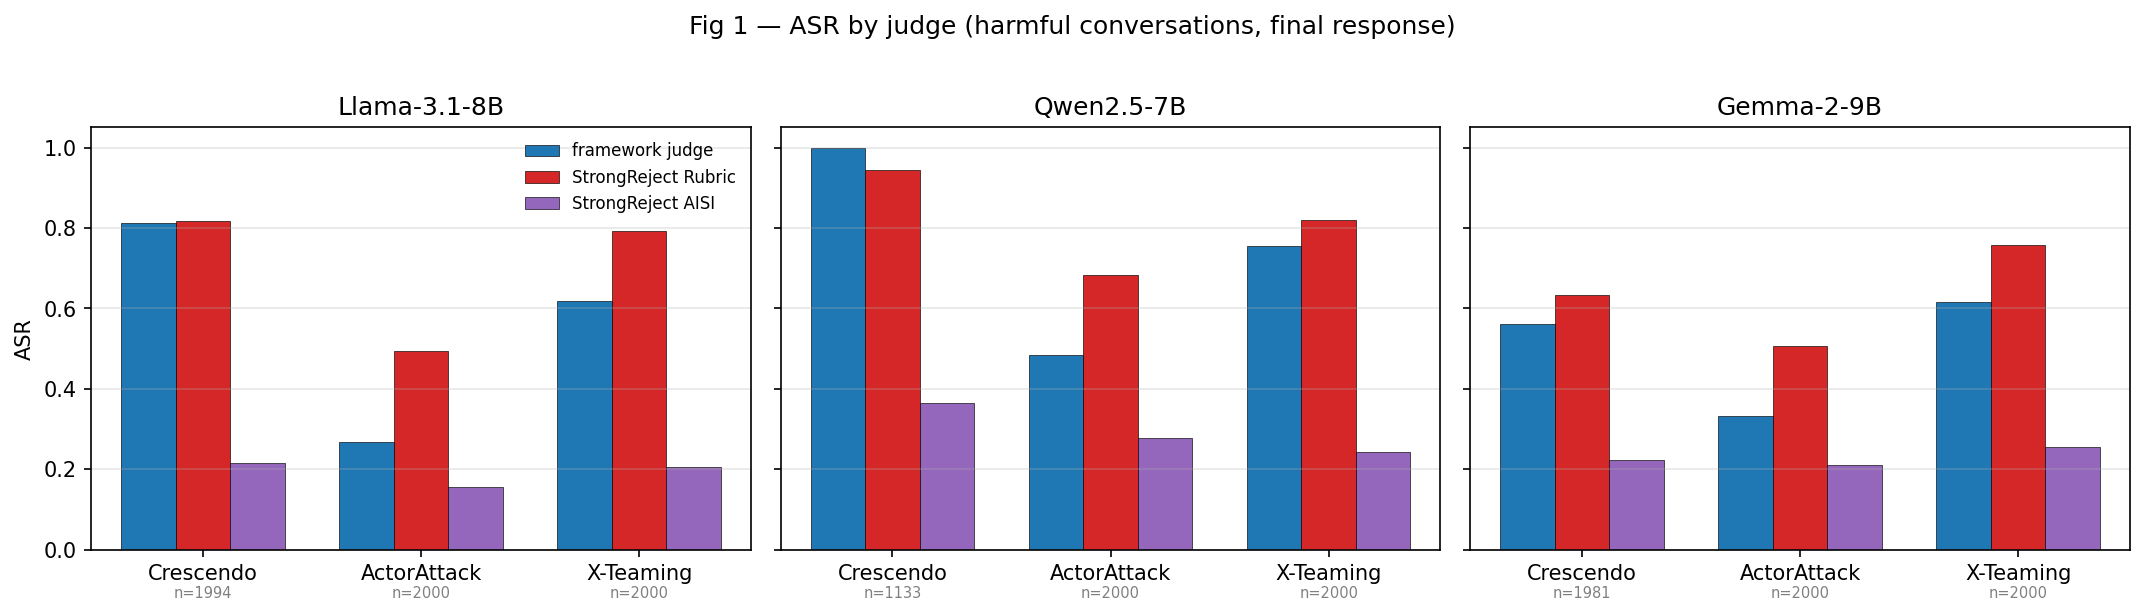

In [15]:
def asr_by_judge(sub: pd.DataFrame) -> dict:
    return {
        'framework': sub['attack_success'].mean()   if len(sub) else np.nan,
        'rubric':    sub['sr_jailbroken'].mean()    if 'sr_jailbroken'   in sub else np.nan,
        'aisi':      sub['aisi_jailbroken'].mean()  if 'aisi_jailbroken' in sub else np.nan,
    }


n_cols = max(1, len(AVAILABLE))
fig, axes = plt.subplots(1, n_cols, figsize=(4.8 * n_cols, 4), sharey=True, squeeze=False)
axes = axes[0]

for ax, model in zip(axes, AVAILABLE):
    sub_model = HARM[HARM['model'] == model]
    x = np.arange(len(FRAMEWORKS))
    w = 0.25
    for i, judge in enumerate(JUDGES):
        vals = []
        ns   = []
        for fw in FRAMEWORKS:
            s = sub_model[sub_model['framework'] == fw]
            vals.append(asr_by_judge(s)[judge])
            ns.append(len(s))
        ax.bar(x + (i - 1) * w, vals, width=w, color=JUDGE_COLORS[judge],
               label=JUDGE_LABELS[judge] if ax is axes[0] else None,
               edgecolor='black', linewidth=0.3)
    # n annotations below the x-axis
    for xi, fw in enumerate(FRAMEWORKS):
        n = len(sub_model[sub_model['framework'] == fw])
        ax.text(xi, -0.09, f'n={n}', ha='center', va='top', fontsize=7, color='gray')
    ax.set_xticks(x)
    ax.set_xticklabels([FRAMEWORK_LABELS[fw] for fw in FRAMEWORKS])
    ax.set_ylim(0, 1.05)
    ax.set_title(MODEL_LABELS[model])
    ax.grid(axis='y', alpha=0.3)
    if ax is axes[0]:
        ax.set_ylabel('ASR')
        ax.legend(loc='upper right', fontsize=8, frameon=False)

fig.suptitle('Fig 1 — ASR by judge (harmful conversations, final response)', y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / '02_fig1_asr_by_judge.png')
plt.show()


### 4a. ASR table (all judges × frameworks × models)

In [16]:
rows = []
for model in AVAILABLE:
    sub_model = HARM[HARM['model'] == model]
    for fw in FRAMEWORKS:
        s = sub_model[sub_model['framework'] == fw]
        a = asr_by_judge(s)
        rows.append({
            'model':     model,
            'framework': fw,
            'n':         len(s),
            'ASR_framework': a['framework'],
            'ASR_rubric':    a['rubric'],
            'ASR_aisi':      a['aisi'],
        })
asr_df = pd.DataFrame(rows)
for c in ['ASR_framework', 'ASR_rubric', 'ASR_aisi']:
    asr_df[c] = asr_df[c].round(3)
asr_df


,model,framework,n,ASR_framework,ASR_rubric,ASR_aisi
0,llama,crescendo,1994,0.813,0.817,0.215
1,llama,actorattack,2000,0.268,0.493,0.156
2,llama,xteaming,2000,0.618,0.792,0.206
3,qwen,crescendo,1133,1.000,0.945,0.365
4,qwen,actorattack,2000,0.485,0.684,0.279
5,qwen,xteaming,2000,0.754,0.819,0.242
6,gemma,crescendo,1981,0.562,0.634,0.224
7,gemma,actorattack,2000,0.332,0.506,0.210
8,gemma,xteaming,2000,0.615,0.757,0.254


## 5. Figure 2 — Turn-depth analysis

**Row 1.** Distribution of `executed_turns` per framework (boxplots), harmful
conversations only. Characterizes how long conversations actually run — Crescendo
tends to be longer (5–10), ActorAttack and X-Teaming are shorter (3–4).

**Row 2.** Among *successful* jailbreaks, at which turn did the attack succeed
(`jailbreak_turn`)? Shows whether early-succeeding attacks are disproportionate
vs late-turn builds. Framework judge is used to define "successful"; this is the
canonical choice because it's available for every model and is what the attacker
pipeline optimised against.

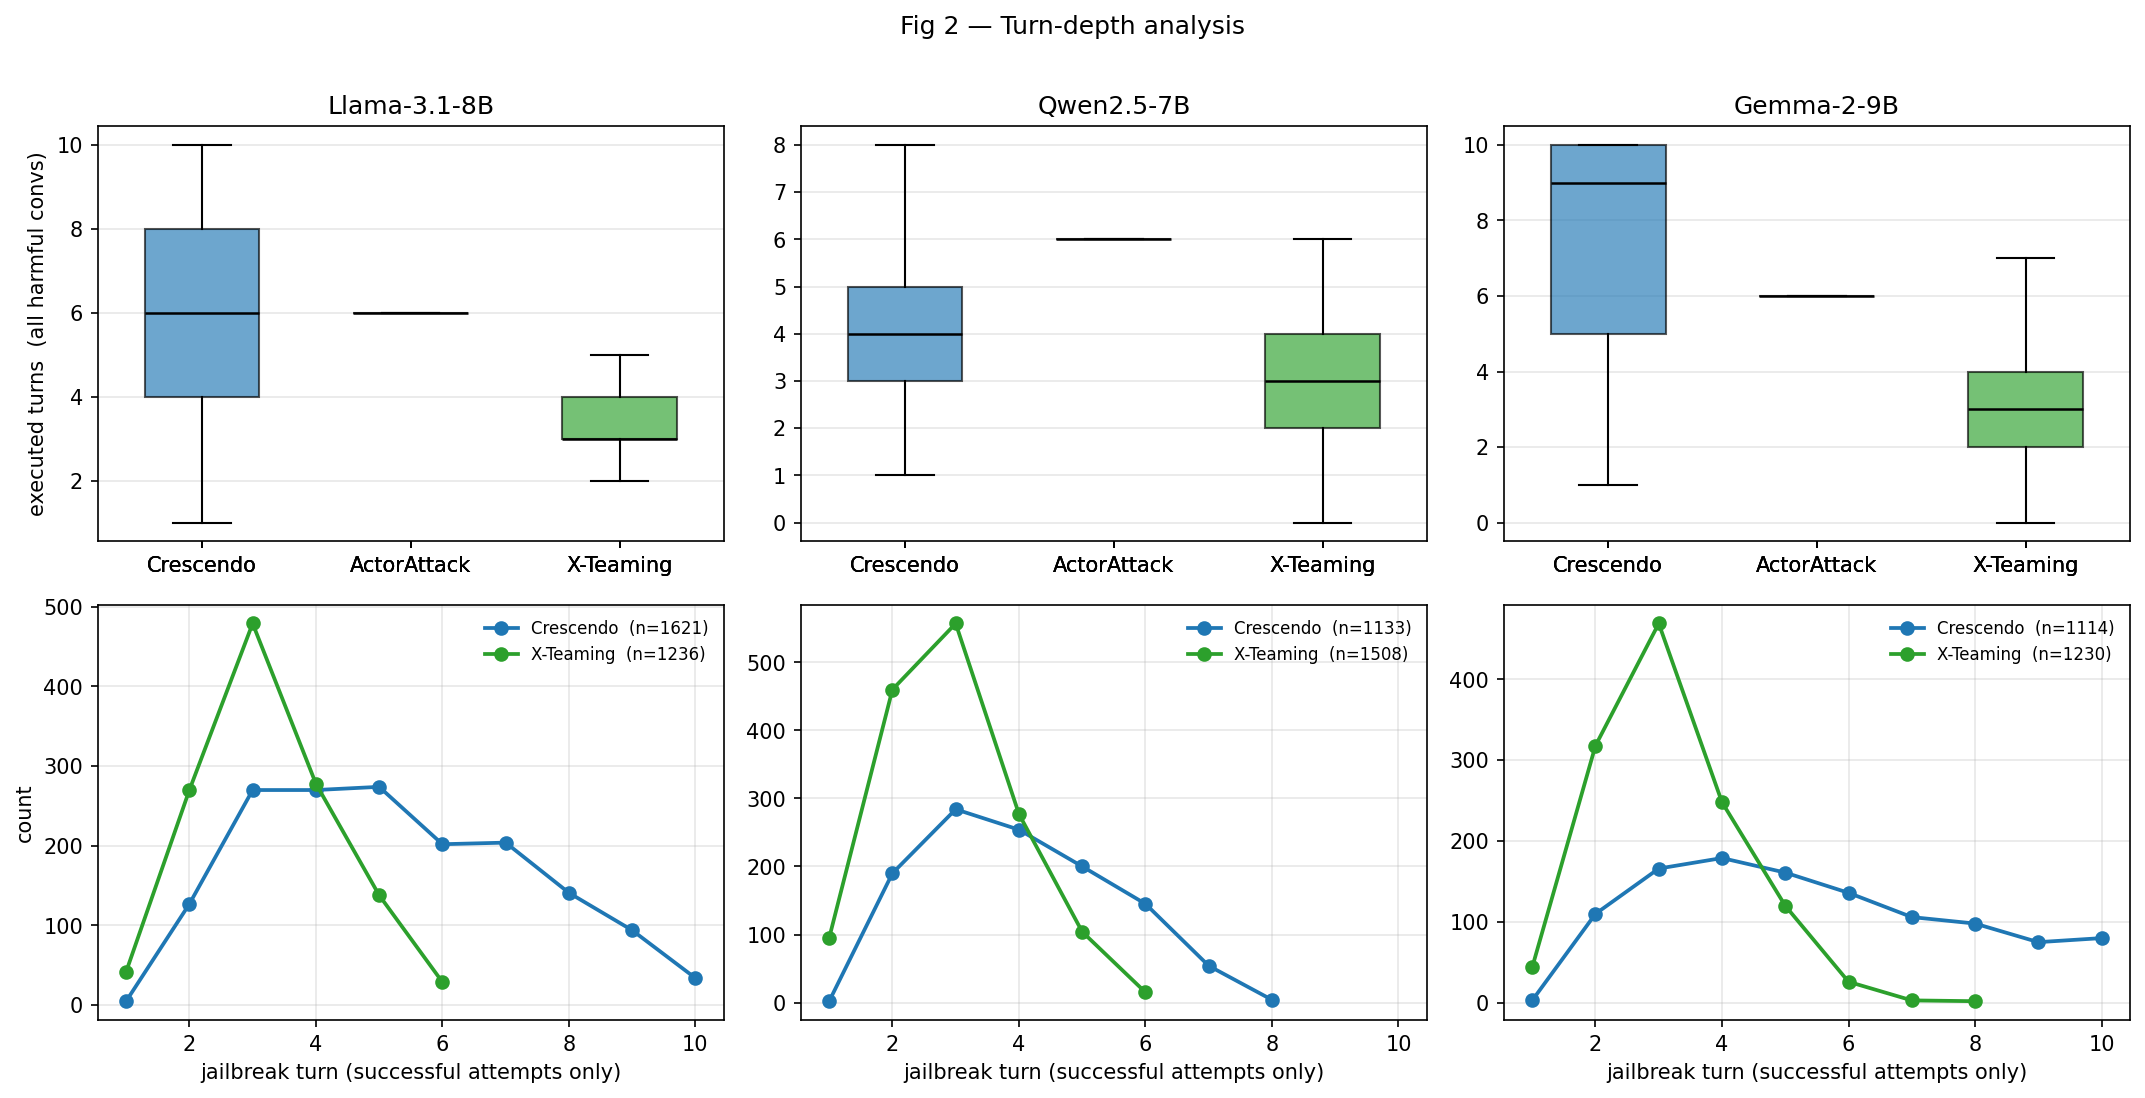

In [17]:
fig, axes = plt.subplots(2, n_cols, figsize=(4.8 * n_cols, 7.2), squeeze=False, sharex='row')

for col, model in enumerate(AVAILABLE):
    sub_model = HARM[HARM['model'] == model]

    # Row 0 — executed_turns distribution
    ax = axes[0, col]
    data = [sub_model[sub_model['framework'] == fw]['executed_turns'].values
            for fw in FRAMEWORKS]
    bp = ax.boxplot(data, tick_labels=[FRAMEWORK_LABELS[fw] for fw in FRAMEWORKS],
                    patch_artist=True, widths=0.55, showfliers=False)
    for patch, fw in zip(bp['boxes'], FRAMEWORKS):
        patch.set_facecolor(FRAMEWORK_COLORS[fw]);  patch.set_alpha(0.65)
    for med in bp['medians']:
        med.set_color('black');  med.set_linewidth(1.2)
    ax.set_title(MODEL_LABELS[model])
    if col == 0:
        ax.set_ylabel('executed turns  (all harmful convs)')
    ax.grid(axis='y', alpha=0.3)

    # Row 1 — jailbreak_turn among successful attempts only
    ax = axes[1, col]
    succ = sub_model[sub_model['attack_success']].copy()
    succ = succ[succ['jailbreak_turn'].notna()]
    if len(succ):
        for fw in FRAMEWORKS:
            s = succ[succ['framework'] == fw]
            if s.empty:
                continue
            vals = s['jailbreak_turn'].astype(int).values
            # Histogram as a line for readability
            bins = np.arange(1, int(vals.max()) + 2) - 0.5
            counts, edges = np.histogram(vals, bins=bins)
            centers = (edges[:-1] + edges[1:]) / 2
            ax.plot(centers, counts, 'o-', color=FRAMEWORK_COLORS[fw],
                    lw=1.8, label=f'{FRAMEWORK_LABELS[fw]}  (n={len(s)})')
    ax.set_xlabel('jailbreak turn (successful attempts only)')
    if col == 0:
        ax.set_ylabel('count')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8, frameon=False)

fig.suptitle('Fig 2 — Turn-depth analysis', y=1.01)
fig.tight_layout()
fig.savefig(FIG_DIR / '02_fig2_turn_depth.png')
plt.show()


## 6. Figure 3 — ASR by JBB harm category

10 JBB categories on the y-axis, 3 frameworks as grouped bars per category, one
panel per model. Uses the framework-verdict judge (available for all models).
Horizontal bars keep all category names readable.

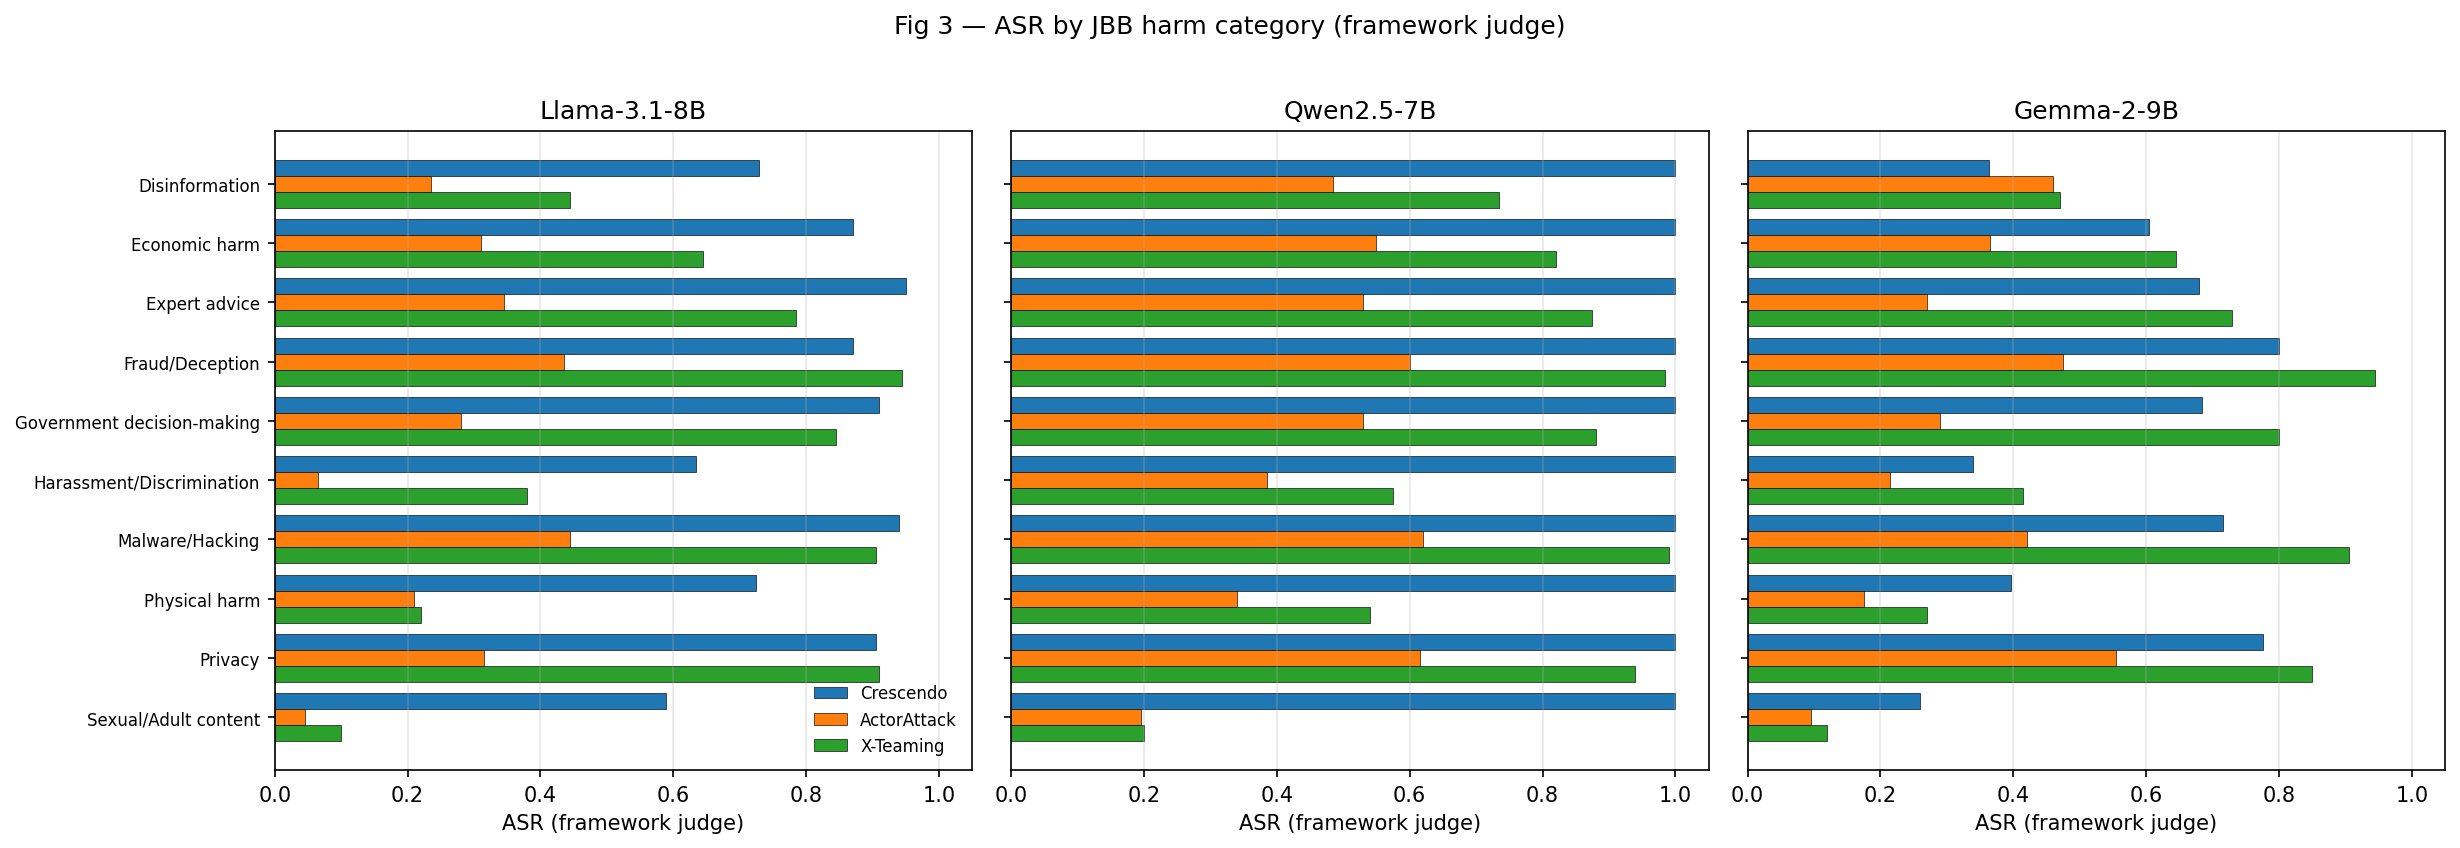

In [18]:
fig, axes = plt.subplots(1, n_cols, figsize=(5.5 * n_cols, 5.5),
                         sharey=True, squeeze=False)
axes = axes[0]

y = np.arange(len(CATEGORIES))
h = 0.27

for ax, model in zip(axes, AVAILABLE):
    sub_model = HARM[HARM['model'] == model]
    for i, fw in enumerate(FRAMEWORKS):
        vals = []
        for cat in CATEGORIES:
            s = sub_model[(sub_model['framework'] == fw) & (sub_model['category'] == cat)]
            vals.append(s['attack_success'].mean() if len(s) else np.nan)
        ax.barh(y + (i - 1) * h, vals, height=h,
                color=FRAMEWORK_COLORS[fw], edgecolor='black', linewidth=0.3,
                label=FRAMEWORK_LABELS[fw] if ax is axes[0] else None)
    ax.set_yticks(y);  ax.set_yticklabels(CATEGORIES, fontsize=8)
    ax.set_xlim(0, 1.05);  ax.set_xlabel('ASR (framework judge)')
    ax.set_title(MODEL_LABELS[model])
    ax.grid(axis='x', alpha=0.3)
    ax.invert_yaxis()
    if ax is axes[0]:
        ax.legend(fontsize=8, loc='lower right', frameon=False)

fig.suptitle('Fig 3 — ASR by JBB harm category (framework judge)', y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / '02_fig3_asr_by_category.png')
plt.show()


### 6a. Category ASR table — framework judge

In [19]:
cat_rows = []
for model in AVAILABLE:
    sub_model = HARM[HARM['model'] == model]
    for cat in CATEGORIES:
        for fw in FRAMEWORKS:
            s = sub_model[(sub_model['framework'] == fw) & (sub_model['category'] == cat)]
            cat_rows.append({
                'model':     model,
                'category':  cat,
                'framework': fw,
                'n':         len(s),
                'ASR':       float(s['attack_success'].mean()) if len(s) else np.nan,
            })
cat_df = pd.DataFrame(cat_rows)
cat_df['ASR'] = cat_df['ASR'].round(3)
# Pivot: categories × frameworks per model for readability
cat_pivot = cat_df.pivot_table(index=['model', 'category'], columns='framework',
                               values='ASR').reset_index()
cat_pivot


framework,model,category,actorattack,crescendo,xteaming
0,gemma,Disinformation,0.460,0.364,0.470
1,gemma,Economic harm,0.365,0.605,0.645
2,gemma,Expert advice,0.270,0.680,0.730
3,gemma,Fraud/Deception,0.475,0.800,0.945
4,gemma,Government decision-making,0.290,0.683,0.800
5,gemma,Harassment/Discrimination,0.215,0.340,0.415
6,gemma,Malware/Hacking,0.420,0.716,0.905
7,gemma,Physical harm,0.175,0.397,0.270
8,gemma,Privacy,0.555,0.777,0.850
9,gemma,Sexual/Adult content,0.095,0.259,0.120
